In [1]:
# runs with xfel (202501)
# Playground for testing things for the automatic XPCS analysis

In [4]:
import json
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import matplotlib.patches as patches # to draw rectangles
import h5py
import hdf5plugin
import pyFAI
import pyFAI.azimuthalIntegrator
import scipy
import time
import re # for regular expressions
import ast

# INPUT

In [3]:
dir_beamtime = Path('/asap3/petra3/gpfs/p10/2025/data/11022562/')

sample_name = 'm067_Ferritin_semiconc_cap3_XPCS_263p6K'
scan_number = 5
detector = 'e4m'
skip_frames_start = 1

filename_mask = dir_beamtime / 'processed/masks_python/mask_e4m_fromP08_2025_09_29.npy'
#filename_poni = dir_beamtime / 'processed/SAXSdetector_2025_08_31.poni' # if you don't have a poni file yet, you can use function 'create_poni_from_batchinfoP10(filename_batchinfo, pixel_size_m)' instead

dir_results = Path('.') # ToDo change according to scan_series etc.

In [4]:
# define the q-partitions
q_centers = np.arange(0.15,0.9,0.05) * 1e9
q_widths = 0.05*np.ones(len(q_centers)) * 1e9

# FUNCTIONS and CLASSES

In [5]:
# global functions
def custom_encoder(obj):
    """
    return: str
    Converts input to string format if necessary. Ensures the content of the object can be written to a JSON file.
    """
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    # add additional options if required
    return str(obj)

def get_delay_info(numberframes, numberdelaysperlevel=4):
    """
    input: int, _int - [#frames, #delays per level]
    return: (np.array(1D), np.array(1D)) - [array of indices, array of levels]
    Calculates the timesteps in units of frames for the different levels of the multitau-algorithm. The second output is an array of the level at each timestep. 
    This level indicates over how many frames the average is taken before the correlation in form of a dot product is calculated.
    E.g., level=0, average over 2^0=1 frames; level=1, average over 2^1=2 frames; level=2, average over 2^2=4 frames; ...
    As default, the number of delays per level is set to 4. 
    To better account for the information given by the early delays, level 0 contains 2*(#delays per level) - 1 -> omit the selfcorrelation at zero delay.
    """
    counter_levels = -1 # counts at what level (0,1,2,...) for the power to base 2 we are (2^0=1, 2^1=2, 2^2=4, ...). Give an additional level -1 at the beginning which counts in integers
    delay_starting_indices = []
    level_per_index = []
    modulo_counter = 1
    next_index = 0
    while next_index < numberframes-np.max((1,2**counter_levels)): # terminate if the next index would exceed numberframes, further ensure that the last entry contains the maximal number of frames so that noise is the lowest
        delay_starting_indices.append(next_index) # add another index
        if modulo_counter == numberdelaysperlevel:
            modulo_counter = 1
            counter_levels += 1
        else:
            modulo_counter += 1
        next_index += np.max((1, 2**counter_levels))
        level_per_index.append(np.max((0,counter_levels)))
    return (np.array(delay_starting_indices, dtype='int')+1, np.array(level_per_index))

def block_average_rows(A,k):
    dim_x, dim_y = np.shape(A)
    number_blocks = int(np.floor(dim_x/k)) # attention, as the last block would contain less frames than the previous, it is omitted
    B = np.zeros((number_blocks, dim_y))

    for i in range(number_blocks):
        next_block = np.arange(i*k,(i+1)*k)
        B[i,:] = np.mean(A[next_block,:], axis=0)

    return B

def multitau(data2D, time_interval=1, layers_per_level=4):
    """
    input: np.array(2D), float, int - [data (dim_#frames, dim_#pixels_xy), time interval in seconds, layers per level in multitau-algorithm]
    return: (np.array(1D), np.array(1D), np.array(1D)) - [delay times, g2, error g2]
    Calculates the autocorrelation function g2 on the basis of a multitau-algorithm. 
    Delay-times are calculated based on the time interval, the number of frames in 2Ddata and the layers per level, making use of function 'getdelayinfo.
    """
    number_frames, number_pixels = data2D.shape
    starting_indices, levels_per_index = get_delay_info(number_frames, layers_per_level)
    number_times_multitau = len(levels_per_index)
    times_multitau = time_interval * starting_indices
    g2 = np.zeros(number_times_multitau)
    g2_error = np.zeros(number_times_multitau)
    # at each level, the next delay is calculated starting from layers_per_level+1 for the correlations.
    current_level = 0
    current_data2D = data2D
    delay_index_within_level = 1
    for i in range(number_times_multitau):
        if levels_per_index[i] > current_level:
            current_level += 1
            current_data2D = block_average_rows(current_data2D,2)
            delay_index_within_level = layers_per_level
        counts_past = current_data2D[:-delay_index_within_level,:].astype(np.float32)
        counts_future = current_data2D[delay_index_within_level:,:].astype(np.float32)
        correlation = counts_past * counts_future # elementwise multiplication averaged over all pixels
        frame_correlation = np.mean(correlation, axis=1) / (np.mean(counts_past, axis=1)*np.mean(counts_future, axis=1))
        g2[i] = np.mean(frame_correlation)
        g2_error[i] = np.std(frame_correlation, ddof=1) / np.sqrt(len(frame_correlation))
        delay_index_within_level += 1

    return(times_multitau, g2, g2_error)

def process_incoherent_image(data3D, mask=None):
    """
    input: np.array(3D), _Mask 
    return: np.array(2D), np.array(2D)
    Calculates the incoherent image of a series of images.
    """
    if data3D.ndim != 3:
        raise ValueError("Dimensions of input array should be three (3D-array).")
    else:
        inc_img = np.mean(data3D, axis=0)
        dim_y, dim_x = inc_img.shape
        if mask is None: # only process the masked incoherent image in case a mask is provided.
            return (inc_img, None)
        if dim_y != mask.dim_y or dim_x != mask.dim_x:
            raise ValueError("Size of input data and mask do not match.")
        else:
            inc_img_cor = np.copy(inc_img)
            inc_img_cor[np.logical_not(mask.array_boolean)] = np.nan
            return (inc_img, inc_img_cor)

def process_SAXS(data2D, pyfai_config, precision_SAXS=600, mask=None):
    """
    input: np.array(2D), pyFAI-config, _int, _Mask
    return: np.array(1D), np.array(1D), np.array(1D)
    Calculates the SAXS curve (including Poisson error) from a 2D detector image. 
    The precission of data points along Q is given by 'precision_SAXS'. As standard, a value of 600 is chosen.
    Optionally, a Mask object that provides information about bad pixels can be handled by the function.
    """
    dim_y, dim_x = data2D.shape
    if (mask is None or dim_y != mask.dim_y or dim_x != mask.dim_x):
        mask_array = None
        print('No mask used')
    else:
        mask_array = np.logical_not(mask.array_boolean) # pyFAI requires the inverted mask
    # calculate SAXS curve
    SAXS_Q, SAXS_IofQ, SAXS_errorIofQ = pyfai_config.integrate1d(data = data2D, # 2D data array
        npt = precision_SAXS,
        unit='q_nm^-1', # unit of x-axis
        mask=mask_array,
        error_model = 'poisson')
    SAXS_Q = SAXS_Q*1e9
    return (SAXS_Q, SAXS_IofQ, SAXS_errorIofQ)

def process_frame_resolved_SAXS(data3D, pyfai_config, precision_SAXS=600, mask=None):
    """
    input: np.array(3D), pyFAI-config, _int, _Mask
    return: np.array(1D), np.array(2D), np.array(2D)
    Calculates the SAXS curve for each frame of a series. Thus, the input is the full dataset with dimensions (#frames, dim_y, dim_x). 
    As output, it returns the Q-values as a 1D-array (as it is the same for each frame) and 2D-arrays (dimension (#frames, #Q-bins)) for the SAXS intensity and error, respectively.
    The input precision SAXS defines the number of Q-values (the resolution).
    Q-values are given in units of 1/nm^-1.
    """
    number_frames, dim_y, dim_x = data3D.shape
    if (mask is None or dim_y != mask.dim_y or dim_x != mask.dim_x):
        mask_array = None
    else:
        mask_array = np.logical_not(mask.array_boolean) # pyFAI requires the inverted mask
    # calculate SAXS curves
    frame_resolved_SAXS_IofQ = np.zeros((number_frames, precision_SAXS))
    frame_resolved_SAXS_errorIofQ = np.zeros((number_frames, precision_SAXS))
    for idx_frame in range(number_frames):
        SAXS_Q, next_IofQ, next_errorIofQ = pyfai_config.integrate1d(data = data3D[idx_frame,:,:],
            npt = precision_SAXS,
            unit='q_nm^-1', # unit of x-axis
            mask=mask_array,
            error_model = 'poisson')
        frame_resolved_SAXS_IofQ[idx_frame,:] = next_IofQ
        frame_resolved_SAXS_errorIofQ[idx_frame,:] = next_errorIofQ
    return SAXS_Q*1e9, frame_resolved_SAXS_IofQ, frame_resolved_SAXS_errorIofQ

def evolution_SAXS(data3D, pyfai_config, precision_SAXS=600, segments=10, mask=None):
    """
    input: np.array(3D), pyFAI-config, _int, _int, _Mask
    return: np.array(1D), np.array(2D), np.array(2D)
    Calculates the SAXS curve for a series of frames. The frames are are averaged with the number of chunks defined by segments.
    As default, 10 segments are considered.
    As output, it returns the Q-values as a 1D-array (as it is the same for each frame) and 2D-arrays (dimension (#frames, #Q-bins)) for the SAXS intensity and error, respectively.
    The input precision SAXS defines the number of Q-values (the resolution).
    Q-values are given in units of 1/nm^-1.
    """
    number_frames, dim_y, dim_x = data3D.shape
    if number_frames < segments:
        raise ValueError("The number of segments exceeds the number of frames in the dataset. Consider reducing the number of segments or use function 'process_frame_resolved_SAXS' instead.")
    frames_per_segment = number_frames / segments
    if (mask is None or dim_y != mask.dim_y or dim_x != mask.dim_x):
        mask_array = None
    else:
        mask_array = np.logical_not(mask.array_boolean) # pyFAI requires the inverted mask
    # calculate SAXS curves
    evolution_SAXS_IofQ = np.zeros((segments, precision_SAXS))
    evolution_SAXS_errorIofQ = np.zeros((segments, precision_SAXS))
    for i in range(segments):
        next_data_array = np.nanmean(data3D[int(i*frames_per_segment):int((i+1)*frames_per_segment),:,:], axis=0)
        SAXS_Q, next_IofQ, next_errorIofQ = pyfai_config.integrate1d(data = next_data_array,
            npt = precision_SAXS,
            unit='q_nm^-1', # unit of x-axis
            mask=mask_array,
            error_model = 'poisson')
        evolution_SAXS_IofQ[i,:] = next_IofQ
        evolution_SAXS_errorIofQ[i,:] = next_errorIofQ
    return SAXS_Q*1e9, evolution_SAXS_IofQ, evolution_SAXS_errorIofQ

def calculate_ttcf(data_2D):
    """
    input: np.array(2D) - (#frames, #pixels_xy)
    return: np.array(#frames), int, np.array(#frames, #frames)
    Calculates the two-time correlation function (TTCF) for a 2D np.array with dimensions (#frames, #pixels_xy). 
    This data-format can be retrieved from the standard raw-dataset of an XPCS experiment (dimensions (#frames, dim_y, dim_x)) via ToDO
    """
    # ensure that data_2D is of dtype float32 (helps to speed up calculations)
    if data_2D.dtype == 'float32':
        data = data_2D
    else:
        data = data_2D.astype('float32')
    # calculate variation in intensity per frame
    intensity_change = np.mean(data_2D, axis=1)
    # determine number of pixels
    number_of_pixels = data_2D.shape[1]
    # calculate ttc via dot-product
    ttc = np.dot(data, np.transpose(data))
    #tmp_ttc_triangle = scipy.linalg.blas.dsyrk(alpha=1.0, a=data_2D, beta=0.0, trans=False, lower=False)
    #tmp_ttc_full = tmp_ttc_triangle + tmp_ttc_triangle.T - np.diag(np.diag(tmp_ttc_triangle))
    ttc_norm = ttc / np.outer(intensity_change, intensity_change) / number_of_pixels
    return intensity_change, number_of_pixels, ttc_norm

def calculate_g2(ttcf):
    """ 
    input: np.array(2D)
    return: np.array(1D)
    Calculates the autocorrelation function as diagonal cuts from the two-time correlation function.
    According to [O. Bikondoa, J. Appl. Cryst. (2017), 50, 357-68], these cuts are referred to 'alternative coordinate system' (ACS).   
    """
    g2 = np.array([np.nanmean(np.diagonal(ttcf, offset=i)) for i in range(1,(ttcf.shape[0]))])
    return g2

def perform_diagonal_cut4ttcf(ttcf, idx_center, idx_width):
    """
    input: np.array(2D)
    return: np.array(1D)
    """
    dim_steps, _ = ttcf.shape
    included_data = np.full((dim_steps, dim_steps), np.nan)
    idx_min = np.max([0,int(idx_center - idx_width/2)])
    idx_max = np.min([dim_steps,int(idx_center + idx_width/2)]) 
    for i in range(idx_min, idx_max):
        np.fill_diagonal(included_data[:, i:], 1)
    included_data = np.flipud(included_data.transpose())
    g2_diagonal_cut = calculate_g2(np.multiply(ttcf,included_data))
    return g2_diagonal_cut

def perform_horizontal_cut4ttcf(ttcf, idx_center, idx_width):
    """
    """
    dim_steps, _ = ttcf.shape
    included_data = np.full((dim_steps, dim_steps), np.nan)
    idx_min = np.max([0,int(idx_center - idx_width/2)])
    idx_max = np.min([dim_steps,int(idx_center + idx_width/2)])
    included_data[idx_min:idx_max,:] = 1 # note that this extends over the diagonal, but the function calculate_g2 only calculates everything below the diagonal    
    g2_horizontal_cut = calculate_g2(np.multiply(ttcf,included_data))
    return g2_horizontal_cut

def perform_vertical_cut4ttcf(ttcf, idx_center, idx_width):
    """
    """
    dim_steps, _ = ttcf.shape
    included_data = np.full((dim_steps, dim_steps), np.nan)
    idx_min = np.max([0,int(idx_center - idx_width/2)])
    idx_max = np.min([dim_steps,int(idx_center + idx_width/2)])
    included_data[:,idx_min:idx_max] = 1 # note that this extends over the diagonal, but the function calculate_g2 only calculates everything below the diagonal    
    g2_vertical_cut = calculate_g2(np.multiply(ttcf,included_data))
    return g2_vertical_cut

In [6]:
class AdditionalInfo:
    """
    class AdditionalInfo stores user specific data that can be added as JSON output on top of the standard output during autoXPCS processing.

    Attributes
    ----------
    description : str
        Description of the content. A standard text is provided during initialization.
    content : dict
        Dictionary containing user specific data provided as key-value pairs. Values can be str, numbers, lists, np.arrays (get converted to lists during print()), dictionaries, etc.
    """
    def __init__(self):
        """
        Initialize an instance with a standard description for the attribute 'description'. 'Content' is initialized as an empty dictionary.
        """
        self.description = 'This section contains information provided by the user. All information is stored in a dictionary and the content can be loaded from the json file using json.load().'
        self.content = {}

    def add_content(self, key, value):
        """
        Add content to the attribute 'content' (dictionary) in the form of (key, value)-pairs. The values can be of type str, number, list, np.array (gets converted to list), dictionary.  
        """
        self.content[key] = value

    def create_dict_output(self):
        """
        return: dict
        Creates a single dictionary as output with the keys 'Description' and 'Content'. Note that depending on the content, the output of this function also can be a nested dictionary. 
        The output is ready for writing in a JSON file.
        """
        all_parameters = {'Description': self.description, 'Content': self.content}
        return all_parameters

    def __str__(self):
        """
        return: str
        Returns the object as a JSON file.
        """
        return json.dumps(self.create_dict_output(), indent=4, default=custom_encoder)

In [7]:
class Mask:
    """
    class Mask stores the mask used to indicate good (1) and bad (0) pixels.

    Attributes
    ----------
    filename : pathlib.Path
        Absolute path where the mask is saved as numpy array.
    array : np.array()
        Mask given as a numpy array where good (1) and bad (0) pixels are distinguished.
    array_boolean : np.array()
        Same as mask but converted to good (True) and bad (False).
    dim_y : int
        Number of pixels in y-direction
    dim_x : int
        Number of pixels in x-direction
    """
    def __init__(self, filename_mask):
        """
        input: Path - (path to the filename where the mask is saved) 
        Initialize an instance with all information obtained from a *.npy file describing good and bad pixels of the detector.
        """
        self.filename = filename_mask
        self.array = np.load(self.filename)
        self.array_boolean = self.array.astype(bool)
        self.dim_y, self.dim_x = self.array.shape

    def create_dict_output(self):
        """
        return: dict
        Creates a single dictionary as output compatible with JSON files.
        """
        all_parameters = {'Filename': str(self.filename), 'Dimensions (y,x)': (self.dim_y, self.dim_x)}
        return all_parameters

    def __str__(self):
        """
        return: str
        Returns the object as a JSON file.
        """
        return json.dumps(self.create_dict_output(), indent=4, default=custom_encoder)

In [8]:
class QPartitions:
    """
    class QPartitions stores arrays used to define pixel selections. It needs to match in dimensions with mask and data.
    Within each partition, included pixels (1) can be distinguished from excluded pixels (0).

    Attributes
    ----------
    filename : pathlib.Path
        Absolute path where the Q-partitions are saved as np.array.
    arrays : np.array()
        Partitions given as a np.arrays where included (1) and excluded (0) pixels are distinguished.
        Is a 3D array that has dimensions (#partitions, dim_y, dim_x)
    number_q_partitions : int
        Number of partitions (0th dimension of arrays).
    dim_y : int
        Number of pixels in y-direction (1st dimension of arrays)
    dim_x : int
        Number of pixels in x-direction (2nd dimension of arrays)
    info : dict
        Dictionary that contains additional information on how the q-partitions have been created (e.g., as Q-rings if similar Q-value)
    """
    def __init__(self):
        """
        Initialize an instance with all attributes defined by dummy values.
        """
        self.filename = 'no file'
        self.arrays = np.array(None)
        self.number_q_partitions = 0
        self.dim_y = 0
        self.dim_x = 0
        self.info = {}

    def define_partitions(self, partition_arrays, info={}):
        """
        input: np.array(3D), _dict - [q-partitions (dim_#partitions, dim_y, dim_x), info]
        Defines the Q-partitions to the instance and updates all attributes.
        Note that if the instance already contains q-partitions or info, these values become overwritten. 
        In case you would like to add partitions to an already existing selection of partitions, use 'add_partitions' instead.
        """
        self.info = info
        self.arrays = np.array(partition_arrays)
        self.number_q_partitions, self.dim_y, self.dim_x = self.arrays.shape

    def add_partitions(self, partition_arrays, info={}):
        """
        """
        # ensure that the existing partitions and new partitions match in dimensions
        add_arrays = np.array(partition_arrays)
        add_number_partitions, add_dim_y, add_dim_x = add_arrays.shape
        if add_dim_y != self.dim_y or add_dim_x != self.dim_x:
            raise ValueError("Dimensions of existing and new partitions do not agree. Consider using 'define_partitions' instead.")
        else:
            # update info (creates a new entry with info on the additional partitions)
            base_key = "additional_partitions"
            key = base_key
            counter = 1
            while key in self.info:
                key = f'{base_key}_{counter}'
                counter += 1
            self.info[key] = info
            # update arrays and #partitions
            self.arrays = np.concatenate((self.arrays, add_arrays), axis=0)
            self.number_q_partitions = self.arrays.shape[0]

    def save_partitions(self, filename_save):
        """
        """
        self.filename = filename_save
        np.save(self.filename, self.arrays)

    def create_dict_output(self):
        """
        return: dict
        Creates a single dictionary as output compatible with JSON files.
        """
        all_parameters = {'Filename': str(self.filename), 'Dimensions (y,x)': (self.dim_y, self.dim_x), '#Partitions': self.number_q_partitions, 'Info': self.info}
        return all_parameters

    def show_partitions2D(self, incoherent_img, v_limits='auto'):
        fig, ax = plt.subplots()
        if v_limits == 'auto':
            v_limits = (np.nanpercentile(incoherent_img, 10), np.nanpercentile(incoherent_img, 90))
        ax.imshow(incoherent_img, vmin=v_limits[0], vmax=v_limits[1], origin='lower', alpha=0.8)
        # define colors
        cmap = plt.get_cmap('jet')
        colors = cmap(np.linspace(0, 1, self.number_q_partitions))
        # plot partitions
        for i in range(self.number_q_partitions):
            next_partition = self.arrays[i]
            next_partition[next_partition==0] = np.nan
            next_overlay = next_partition[..., np.newaxis] * colors[i]
            ax.imshow(next_overlay, alpha=0.5, origin='lower')
        plt.show()

In [9]:
class QRings:
    """
    class QRings is intended to create Q-partitions from information given by a poni file and detector dimensions. 
    It can be used as an input for creating an instance of QPartitions.
    Within each partition, included pixels (1) can be distinguished from excluded pixels (0).
    It is especially suitable for SAXS-XPCS and USAXS-XPCS measurements.
    In the future it will also applicable to WAXS-XPCS measurements.

    Attributes
    ----------
    arrays : np.array()
        Partitions given as a np.arrays where included (1) and excluded (0) pixels are distinguished.
        Is a 3D array that has dimensions (#partitions, dim_y, dim_x)
    dim_y : int
        Number of pixels in y-direction (1st dimension of arrays)
    dim_x : int
        Number of pixels in x-direction (2nd dimension of arrays)
    info : dict
        Dictionary that contains additional information on how the q-partitions have been created (e.g., as Q-rings if similar Q-value)
    """
    def __init__(self):
        self.arrays = np.array(None)
        self.dim_y = 0
        self.dim_x = 0
        self.info = {}

    def q_partitions_from_q_rings(self, q_centers, q_widths, detector_shape, poni_info):
        """
        input: np.array, np.array, (int, int), pyFAI-poni
        Generates matrices with the shape of the detector that define which pixels are included in a given ring. 
        Also updates the attribute 'info', a dictionary that contains the information on how these Q-rings have been determined.
        Check 'help(QRings)' for further information.
        """
        self.dim_y, self.dim_x = detector_shape
        q_map = poni_info.qArray(detector_shape) # can be used to get the q-value for each pixel. The output is given in units of 1/nm.
        q_map_inversem = np.array(q_map)*1e9
        q_mins = q_centers - q_widths/2
        q_maxs = q_centers + q_widths/2
        number_partitions = len(q_centers)
        partitions = np.zeros((number_partitions, self.dim_y, self.dim_x))
        for i in range(number_partitions):
            partitions[i,:,:] = np.logical_and(q_map_inversem > q_mins[i], q_map_inversem < q_maxs[i])
        self.arrays = partitions
        self.info['description'] = 'Q-partitions defined as Q-rings'
        self.info['number_partitions'] = number_partitions
        self.info['q_centers'] = q_centers
        self.info['q_widths'] = q_widths

    def show_q_rings(self, SAXS_Q, SAXS_IofQ, y_limits=None):
        fig, ax = plt.subplots()
        ax.plot(SAXS_Q*1e-9, SAXS_IofQ)
        if y_limits is None:
            y_limits = (0.9*np.nanmin(SAXS_IofQ), 1.1*np.nanmax(SAXS_IofQ))
        ax.set_yscale('log')
        ax.set_ylim(y_limits)
        q_centers = self.info['q_centers']
        q_widths = self.info['q_widths']
        q_mins = q_centers - q_widths/2
        num_rings = len(q_widths)
        # define colors for ymap
        cmap = plt.get_cmap('jet')
        colors = cmap(np.linspace(0, 1, num_rings))
        for i in range(num_rings):
            rectangle = patches.Rectangle((q_mins[i]*1e-9, y_limits[0]), q_widths[i]*1e-9, y_limits[1] - y_limits[0], alpha=0.4, edgecolor='black', facecolor=colors[i], linewidth=1)
            ax.add_patch(rectangle)
        plt.show()

In [10]:
class Sample:
    """
    class Sample contains the info about the beamtime(Path) and the sample name (str).
    """
    def __init__(self, dir_beamtime, sample_name):
        self.dir_beamtime = Path(dir_beamtime)
        self.sample_name = sample_name
        self.info = {}
        self.info['dir_beamtime'] = str(self.dir_beamtime)
        self.info['sample_name'] = str(self.sample_name)

In [11]:
class ScanCollection:
    """
    At P10, different types of XPCS-scans exist, namely 'series', 'dscan' and 'meshscan'. 
    The later two contain multiple series of scans, all aquired with the same parameters except for one (dscan) or two (meshscan) motors (e.g., motor 'samx' to scan the sample in x-direction).
    This allows for example to perform position resolved XPCS, but also is of advantage to average XPCS data of identical scans of a given sample. 
    While series is defined separately, ScanCollection allows to perform the same type of analysis for all scans of a dscan/meshscan.

    Attributes
    ----------
    sample : Sample
        Sample object that contains the directory of the beamtime and the sample name
    detector : str
        Detector abbreviation, used for loading data (in the case of P10, DESY) but also used to distinguish between different detectors that record data at the same time.
    scan_number : int
        Specifies the sample in combination with the sample name.
    skip_frames_start=0 : int
        At P10, the shutter might open over the cause of the first few frames recorded. Thus, these frames contain data that is not of use for XPCS analysis. 
        Note that the shutter speed at P10 is approximately 13 ms. Thus, especially scans with an exposure time shorter or equal to 13 ms suffer significantly from the opening of the shutter on the first frame(s).
    scan : Scan
        Scan object. The Scan object presents one of the spots 

    """
    def __init__(self, sample, detector, scan_number, skip_frames_start=0):
        self.sample = sample
        self.detector = detector
        self.scan_number = scan_number
        self.skip_frames_start = skip_frames_start
        self.scan = None
        self.counter_scan_series = 0

    def load_scan(self, scan, counter_scan_series = None):
        self.scan = scan
        if counter_scan_series is None:
            self.counter_scan_series = counter_scan_series + 1
        else:
            self.counter_scan_series = counter_scan_series

In [12]:
class ScanSeries:
    """
    """
    def __init__(self, sample, detector, scan_number, skip_frames_start=0):
        self.sample = sample
        self.detector = detector
        self.scan_number  = scan_number
        self.skip_frames_start = skip_frames_start
        self.filenames_raw_data = []
        self.raw_data = None
        self.number_frames = None
        self.dim_x = None
        self.dim_y = None
        self.experimental_parameters = {}
        self.delay_time_s = None
        self.exposure_time_s = None
        self.mask = None
        self.input = {}
        self.input['sample'] = sample.info
        self.input['detector'] = detector
        self.input['scan_number'] = scan_number
        self.input['skip_frames_start'] = skip_frames_start

    def add_mask(self, mask):
        """
        input: mask
        Add Mask-object as parameter to a Scan-object. Update mask to info.
        """
        self.mask = mask
        self.input['mask'] = mask.create_dict_output()

    def add_filenames_raw_data(self, filenames_raw_data):
        self.filenames_raw_data = filenames_raw_data
        self.input['filenames_raw'] = filenames_raw_data

    def add_raw_data(self, raw_data):
        self.raw_data = raw_data
        self.number_frames, self.dim_y, self.dim_x = raw_data.shape
        self.input['number_frames'] = self.number_frames
        self.input['dim_y'] = self.dim_y
        self.input['dim_x'] = self.dim_x

    def add_delay_time(self, delay_time, exposure_time=None):
        """
        input: float, _float
        Adds the parameters 'delay_time' and 'exposure_time' to the ScanSeries object. 
        These two parameters can differ in case of a dark time as is the case at P10, DESY. If they are the same, only 'delay_time' needs to be provided as input.
        """
        self.delay_time = delay_time
        if exposure_time is None:
            self.exposure_time = delay_time
        else:
            self.exposure_time = exposure_time

    def calculate_ttcfs(self, q_partitions):
        """
        input: QPartitions
        return: np.array(2D), np.array(3D), np.array(1D)
        Calculates the two-time correlation function for each partition provided by 'q_partitions' for the ScanSeries.
        """
        data_3D = self.raw_data[self.skip_frames_start:,:,:]
        number_frames_analyzed = self.number_frames - self.skip_frames_start
        # initialize dummy arrays
        intensities_per_q_partition = np.zeros((q_partitions.number_q_partitions, number_frames_analyzed))
        pixels_per_q_partition = np.zeros(q_partitions.number_q_partitions)
        ttc_per_q_partition = np.zeros((q_partitions.number_q_partitions, number_frames_analyzed, number_frames_analyzed))
        # calculate ttc for each partition
        for i in range(q_partitions.number_q_partitions):
            # combine general mask and q-partition
            if self.mask is None:
                next_mask = q_partitions.arrays[i]
            else:
                next_mask = np.logical_and(q_partitions.arrays[i,:,:],self.mask.array_boolean)
            # reduce dataset from 3D (number_frames, dim_y, dim_x) to 2D (number_frames, dim_xy) with dim_xy determined by the mask
            next_data_2D = data_3D[:,next_mask]
            # calculate ttc
            next_intensity_per_q_partition, next_number_of_pixels, next_ttc = calculate_ttcf(next_data_2D)
            intensities_per_q_partition[i,:] = next_intensity_per_q_partition
            pixels_per_q_partition[i] = next_number_of_pixels
            ttc_per_q_partition[i,:,:] = next_ttc
        return (intensities_per_q_partition, ttc_per_q_partition, pixels_per_q_partition)

    def calculate_all_g2s(self, ttcfs):
        number_frames_analyzed = self.number_frames - self.skip_frames_start
        number_partitions, number_frames_ttc, _ = ttcfs.shape
        if number_frames_ttc != number_frames_analyzed:
            raise ValueError("Attention, dimensions according to ScanSeries do not match with ttcf size.")
        g2_functions = np.zeros((number_partitions,number_frames_analyzed - 1)) # omit self-correlation
        for i in range(number_partitions):
            g2_functions[i,:] = calculate_g2(ttcfs[i])
        return g2_functions

    def calculate_g2s_multitau(self, q_partitions, layers_per_level=4):
        """
        """
        data_3D = self.raw_data[self.skip_frames_start:,:,:]
        number_frames_analyzed = self.number_frames - self.skip_frames_start
        g2s_multitau = []
        g2errors_multitau = []
        # calculate g2s_multitau for each partition
        for i in range(q_partitions.number_q_partitions):
            # combine general mask and q-partition
            if self.mask is None:
                next_mask = q_partitions.arrays[i]
            else:
                next_mask = np.logical_and(q_partitions.arrays[i,:,:],self.mask.array_boolean)
            # reduce dataset from 3D (number_frames, dim_y, dim_x) to 2D (number_frames, dim_xy) with dim_xy determined by the mask
            next_data_2D = data_3D[:,next_mask]
            times_multitau, next_g2_multitau, next_g2error_multitau = multitau(next_data_2D, layers_per_level=4)
            g2s_multitau.append(next_g2_multitau)
            g2errors_multitau.append(next_g2error_multitau)
        return (times_multitau, np.array(g2s_multitau), np.array(g2errors_multitau))

    def add_input(self, input_dict, specifier=None):
        if specifier is None:
            self.input.update(input_dict)
        else:
            self.input[specifier] = input_dict
        

In [13]:
# Visualization tools
def show_incoherent_img(inc_img, mask=None, v_limits='auto'):
    if mask is None:
        if v_limits == 'auto':
            v_limits = (np.percentile(inc_img, 10), np.percentile(inc_img, 90)) # automatically set the color bar limits within [10%-90%] of the data range
        plt.figure()        
        img = plt.imshow(inc_img, vmin=v_limits[0], vmax=v_limits[1], origin='lower')
        plt.colorbar(img)
        plt.xlabel(r'Pixel$_x$')
        plt.ylabel(r'Pixel$_y$')
        plt.tight_layout()
        plt.show()
    else:
        inc_img_cor = np.multiply(inc_img, mask.array)
        if v_limits == 'auto':
            v_limits = (np.percentile(inc_img_cor, 10), np.percentile(inc_img_cor, 90)) # automatically set the color bar limits within [10%-90%] of the data range
        fig, ax = plt.subplots(1,3, figsize=(12,4))
        img_original = ax[0].imshow(inc_img, vmin=v_limits[0], vmax=v_limits[1], origin='lower')
        fig.colorbar(img_original, ax=ax[0])
        ax[0].set_title('Incoherent Img.')
        ax[0].set_xlabel(r'Pixel$_x$')
        ax[0].set_ylabel(r'Pixel$_y$')
        # mask
        ax[1].imshow(mask.array, origin='lower')
        ax[1].set_title('Mask')
        ax[1].set_xlabel(r'Pixel$_x$')
        ax[1].set_ylabel(r'Pixel$_y$')
        # corrected image
        img_cor = ax[2].imshow(inc_img_cor, vmin=v_limits[0], vmax=v_limits[1], origin='lower')
        fig.colorbar(img_cor, ax=ax[2])
        ax[2].set_title('Corrected Img.')
        ax[2].set_xlabel(r'Pixel$_x$')
        ax[2].set_ylabel(r'Pixel$_y$')
        plt.tight_layout()
        plt.show()
        
def show_SAXS_curve(SAXS_Q, SAXS_IofQ, SAXS_errorIofQ=None, y_limits='auto'):
    if y_limits == 'auto':
        y_limits = (0.9*np.nanmin(SAXS_IofQ),1.1*np.nanmax(SAXS_IofQ))
    plt.figure()
    if SAXS_errorIofQ is None:
        plt.plot(SAXS_Q*1e-9, SAXS_IofQ)
    else:
        plt.errorbar(SAXS_Q*1e-9, SAXS_IofQ, yerr=SAXS_errorIofQ)
    plt.xlabel(r'Q (nm$^{-1}$)')
    plt.ylabel('Counts (arb. u.)')
    plt.yscale('log')
    plt.ylim(y_limits)
    plt.show()

def show_evolution_plots(common_x, all_y, norm_reference_idx=0):
    colorbar_limits = (np.percentile(all_y, 10), np.percentile(all_y, 90))
    
    # waterfall plot
    waterfall_dim_y, waterfall_dim_x = all_y.shape
    fig, ax = plt.subplots(1,3, figsize=(14,4))
    pcm = ax[0].pcolormesh(common_x, np.arange(waterfall_dim_y), all_y, shading='auto', cmap='viridis', norm=LogNorm(vmin=colorbar_limits[0], vmax=colorbar_limits[1]))
    plt.colorbar(pcm, label='Intensity (arb. u.)')
    ax[0].set_ylabel('#Steps')
    ax[0].set_title('Absolute Intensity')

    # waterfall plot as difference to reference
    relative_data = (all_y - all_y[norm_reference_idx,:]) / all_y[norm_reference_idx,:]
    relative_data_limits = (np.percentile(relative_data, 10), np.percentile(relative_data, 90))
    pcm = ax[1].pcolormesh(common_x, np.arange(waterfall_dim_y), relative_data, shading='auto', cmap='viridis', vmin=relative_data_limits[0], vmax=relative_data_limits[1])#, norm=LogNorm(vmin=relative_data_limits[0], vmax=relative_data_limits[1]))
    plt.colorbar(pcm, label='Relative Intensity (arb. u.)')
    ax[1].set_ylabel('#Steps')
    ax[1].set_title('Relative Intensity')
    
    # change in data all plotted together
    cmap = plt.get_cmap('viridis')
    colors = cmap(np.linspace(0, 1, waterfall_dim_y))
    for idx_y in range(waterfall_dim_y):
        if idx_y == 0:
            ax[2].semilogy(common_x, all_y[idx_y,:], color=colors[idx_y], label='Start')
        elif idx_y == waterfall_dim_y - 1:
            ax[2].semilogy(common_x, all_y[idx_y,:], color=colors[idx_y], label='End')
        else:
            ax[2].semilogy(common_x, all_y[idx_y,:], color=colors[idx_y], label='')
    plt.legend()
    plt.tight_layout() 
    plt.show()

def get_auto_plot_limits_ttcf(ttcf, percentil_min=25, percentil_max=75):
    tmp = np.copy(ttcf)
    np.fill_diagonal(tmp, np.nan)
    v_limits = (np.nanpercentile(tmp, percentil_min), np.nanpercentile(tmp, percentil_max))
    return v_limits

def show_single_ttcf(ttcf, v_limits='auto'):
    if v_limits == 'auto':
        v_limits = get_auto_plot_limits_ttcf(ttcf)
    plt.figure()
    img = plt.imshow(ttcf, vmin=v_limits[0], vmax=v_limits[1], origin='lower')
    plt.colorbar(img)
    plt.xlabel('#frames')
    plt.ylabel('#frames')
    plt.tight_layout()
    plt.show()

def show_all_ttcf(all_ttcf, v_limits='auto'):
    number_ttcfs, _, _ = all_ttcf.shape
    plot_columns = 4
    plot_rows = int(np.ceil(number_ttcfs / plot_columns))
    subfigure_size = 3
    fig, axes = plt.subplots(plot_rows, plot_columns, figsize=(plot_columns * subfigure_size, plot_rows*subfigure_size))
    axes = axes.flatten()
    if v_limits == 'auto':
        auto_determine_limits = True
    for i in range(number_ttcfs):
        if auto_determine_limits:
            v_limits = get_auto_plot_limits_ttcf(all_ttcf[i,:,:], percentil_min=40, percentil_max=60)
        img = axes[i].imshow(all_ttcf[i,:,:], vmin=v_limits[0], vmax=v_limits[1], origin='lower')
        plt.colorbar(img)
        axes[i].set_xlabel('#frames')
        axes[i].set_ylabel('#frames')
        axes[i].set_title(f'TTCF #{i}')
    plt.tight_layout()
    plt.show()
        
def show_single_g2(times_s, g2, g2error=None, y_limits='auto'):
    plt.figure()
    if g2error is None:
        plt.plot(times_s, g2)
    else:
        plt.errorbar(times_s, g2, yerr=g2error)
    plt.xscale('log')
    if y_limits != 'auto':
        plt.ylim(y_limits)
    plt.xlabel('Time (s)')
    plt.ylabel('g2')
    plt.show()

def show_all_g2s(times_s, g2s, g2errors=None, y_limits='auto'):
    number_g2s = g2s.shape[0]
    cmap = plt.get_cmap('viridis')
    colors = cmap(np.linspace(0, 1, number_g2s))
    plt.figure()
    for i in range(number_g2s):
        if g2errors is None:
            plt.plot(times_s, g2s[i,:], color=colors[i], label=f'g2 #{i}')
        else:
            plt.errorbar(times_s, g2s[i,:], yerr=g2errors[i,:], color=colors[i], label=f'g2 #{i}')
    plt.xscale('log')
    if y_limits != 'auto':
        plt.ylim(y_limits)
    plt.xlabel('Time (s)')
    plt.ylabel('g2')
    plt.legend(loc="upper left",bbox_to_anchor=(1.05, 1))
    plt.tight_layout()
    plt.show()

def show_all_g2s_separately(times_s, g2s, g2errors=None, y_limits='auto'):
    number_g2s = g2s.shape[0]
    plot_columns = 4
    plot_rows = int(np.ceil(number_g2s / plot_columns))
    subfigure_size = 3
    fig, axes = plt.subplots(plot_rows, plot_columns, figsize=(plot_columns * subfigure_size, plot_rows*subfigure_size))
    axes = axes.flatten()
    for i in range(number_g2s):
        if g2errors is None:
            axes[i].plot(times_s, g2s[i,:])
        else:
            axes[i].errorbar(times_s, g2s[i,:], yerr=g2errors[i,:])
        if y_limits != 'auto':
            axes[i].ylim(y_limits)
        axes[i].set_xlabel('Time (s)')
        axes[i].set_ylabel('g2')
        axes[i].set_xscale('log')
        axes[i].set_title(f'g2 #{i}')
    plt.tight_layout()
    plt.show()

In [14]:
# P10 specific functions
def load_data_P10(filenames):
    """"
    input: list of strings
    output: np.array(3D)
    Loads data at beamline P10. Note that the detectors only allow for saving a certain amount of data.
    # Todo: check if this works for larger files.
    """
    data = []
    for filename in filenames:
        with h5py.File(filename, 'r') as f:
            next_data = f['entry/data/data']
            data.append(next_data[:])
    data = np.array(data)
    if data.ndim == 4:
        n_files, n_frames, dim_y, dim_x = data.shape
        data = data.reshape(n_files*n_frames, dim_y, dim_x)
    return data

def create_poni_from_batchinfoP10(scan_series, pixel_size_m=75*1e-6):
    """
    input: str, float - [*.batchinfo filename, detector pixel size (m)]
    return: pyFAI, dict - [poni-file, experimental parameters]
    Creates a poni file from the information given in batchinfo.
    """
    filename_batchinfo = get_filename_batchinfoP10(scan_series)
    with open(filename_batchinfo, 'r') as f:
        for line in f:
            tmp = line.strip().split()
            match tmp[0]:
                case 'energy:':
                    energy_eV = float(tmp[-1])*1e3
                case 'rr:':
                    sample_detector_distance_m = float(tmp[-1])*1e-3
                case 'x0:':
                    x0 = int(tmp[-1])
                case 'y0:':
                    y0 = int(tmp[-1])
                case 'ccdx:':
                    ccdx = float(tmp[1])*1e-3
                case 'ccdz:':
                    ccdz = float(tmp[1])*1e-3
                case 'ccdx0:':
                    ccdx0 = float(tmp[1])*1e-3
                case 'ccdz0:':
                    ccdz0 = float(tmp[-1])*1e-3
                    
    center_x_pixels = x0 + (ccdx - ccdx0) / pixel_size_m
    center_y_pixels = y0 + (ccdz - ccdz0) / pixel_size_m
    wavelength_m = scipy.constants.h * scipy.constants.speed_of_light / (energy_eV * scipy.constants.e)
    # create poni file
    pyfai_config = pyFAI.azimuthalIntegrator.AzimuthalIntegrator(
        dist = sample_detector_distance_m, # distance (m)
        pixel1 = pixel_size_m, # pixel size (m) in y-direction
        pixel2 = pixel_size_m, # pixel size (m) in x-direction
        poni1 = center_y_pixels * pixel_size_m, # position of direct beam (m) in y-direction
        poni2 = center_x_pixels * pixel_size_m, # position of direct beam (m) in x-direction
        rot1 = 0, # rotation of detector (ToDo)
        wavelength = wavelength_m # wavelength (m)
        )
    # create dictionary
    experimental_parameters = {}
    experimental_parameters['energy_eV'] = energy_eV
    experimental_parameters['wavelength_m'] = wavelength_m
    experimental_parameters['sample_detector_distance_m'] = sample_detector_distance_m
    experimental_parameters['direct_beam_(x,y)_pixels'] = (center_x_pixels, center_y_pixels)
    return (pyfai_config, experimental_parameters)

def get_filename_batchinfoP10(scan_series):
    filename_batchinfo = scan_series.sample.dir_beamtime / f'raw/{scan_series.sample.sample_name}_{scan_series.scan_number:05d}/{scan_series.detector}/{scan_series.sample.sample_name}_{scan_series.scan_number:05d}.batchinfo'
    return filename_batchinfo

def get_filenames_series_P10(scan_series):
    filename_batchinfo = get_filename_batchinfoP10(scan_series)
    with open(filename_batchinfo, 'r') as f:
        for line in f:
            if re.search(r'\bndataend\b', line):
                tmp = line.strip()
                _, vec_str = line.split(":", 1)
                vec = ast.literal_eval(vec_str.strip())
    number_files = len(vec)
    filenames = []
    for i in range(number_files):
        filenames.append(scan_series.sample.dir_beamtime / f'raw/{scan_series.sample.sample_name}_{scan_series.scan_number:05d}/{scan_series.detector}/{scan_series.sample.sample_name}_{scan_series.scan_number:05d}_data_{i+1:06d}.h5')
    return filenames

def get_delay_and_exposure_timeP10(scan_series):
    """
    input: ScanSeries
    return: float, float
    Extracts the delay time and exposure time from the master-file at P10, DESY. Note that in the case of a dark time, there is a difference between the two.
    """
    filename_master = scan_series.sample.dir_beamtime / f'raw/{scan_series.sample.sample_name}_{scan_series.scan_number:05d}/{scan_series.detector}/{scan_series.sample.sample_name}_{scan_series.scan_number:05d}_master.h5'
    with h5py.File(filename_master, 'r') as f:
        delay_time = f['entry/instrument/detector/frame_time'][()]
        exposure_time = f['entry/instrument/detector/count_time'][()]
        return (delay_time, exposure_time)

In [15]:
# functions for saving
def save_incoherent_image_results(dir_save, incoherent_img, incoherent_img_cor=None):
    """
    input: str/Path, np.array(2D), _np.array(2D)
    return: dict
    Saves the results of the incoherent image to the folder provided. 
    """
    summary_results = {}
    # incoherent image
    dim_y, dim_x = incoherent_img.shape
    summary_incoherent_img = {'filename': str(dir_save) + '/incoherent_img.npy',
                             'dim_y': dim_y,
                             'dim_x': dim_x}
    summary_results['incoherent_img'] = summary_incoherent_img
    np.save(Path(dir_save) / 'incoherent_img.npy', incoherent_img)
    if incoherent_img_cor is not None:
        dim_y, dim_x = incoherent_img_cor.shape
        summary_incoherent_img_cor = {'filename': str(dir_save) + '/incoherent_img_cor.npy',
                                     'dim_y': dim_y,
                                     'dim_x': dim_x}
        summary_results['incoherent_img_cor'] = summary_incoherent_img_cor
        np.save(Path(dir_save) / 'incoherent_img_cor.npy', incoherent_img_cor)
    return summary_results

def save_SAXS_results(dir_save, filename_save_general, SAXS_Q, SAXS_IofQ, SAXS_errorIofQ=None):
    """
    input: str/Path, str, np.array(1D), np.array(1/2D), _np.array(1/2D)
    return: dict
    ToDO
    """
    summary_results = {}
    precision = len(SAXS_Q)
    np.save(Path(dir_save) / f'{filename_save_general}_Q.npy', SAXS_Q)
    if SAXS_IofQ.ndim == 1:
        number_curves = 1
    else:
        number_curves = SAXS_IofQ.shape[0]
    summary_results = {'precision': precision,
                       'number_curves': number_curves,
                       'Q': str(dir_save) + f'{filename_save_general}_Q.npy',
                       'IofQ': str(dir_save) + f'{filename_save_general}_IofQ.npy'}
    if SAXS_errorIofQ is None:
        summary_results['description'] = 'Dimension of IofQ is (number_curves, precision).'
        np.save(Path(dir_save) / f'{filename_save_general}_IofQ.npy', SAXS_IofQ)
    else:
        summary_results['description'] = 'Dimension of IofQ is (2, number_curves, precision), where IofQ[0,:,:] contains IofQ and IofQ[1,:,:] contains errorIofQ.'
        data_save = np.stack((SAXS_IofQ, SAXS_errorIofQ), axis=0)
        np.save(Path(dir_save) / f'{filename_save_general}_IofQ.npy', data_save)
    return summary_results  

def save_Q_partitions(dir_save, q_partitions):
    """
    input: str/Path, QPartitions
    return: dict
    """
    summary_results = q_partitions.info
    summary_results['filename'] = str(dir_save) + '/q_partitions.npy'
    np.save(Path(dir_save) / 'q_partitions.npy', q_partitions.arrays)
    return summary_results

def save_results_TTCF(dir_save, intensities_per_partition, ttc_per_partition, pixels_per_partition):
    """
    input:
    return: dict
    """
    summary_results = {'intensities_per_partition': str(dir_save) + '/intensities_per_partition.npy',
                      'ttc_per_partition': str(dir_save) + '/ttc_per_partition.npy',
                      'pixels_per_partition': pixels_per_q_partition,
                      'description': 'intensities: (#partitions,#frames); ttc: (#partitions,#frames,#frames)'}
    np.save(Path(dir_save) / 'intensities_per_partition.npy', intensities_per_partition)
    np.save(Path(dir_save) / 'ttc_per_partition.npy', ttc_per_partition)
    return summary_results

def save_results_g2(dir_save, filename_save_general, times, g2s):
    """
    input:
    return: dict
    """
    summary_results = {'filename_times': str(dir_save) + f'/{filename_save_general}_times.npy',
                      'filename_g2s': str(dir_save) + f'/{filename_save_general}_g2s.npy'}
    np.save(Path(dir_save) / f'{filename_save_general}_times.npy', times)
    np.save(Path(dir_save) / f'{filename_save_general}_g2s.npy', g2s)
    return summary_results

# Processing

In [16]:
sample = Sample(dir_beamtime=dir_beamtime, sample_name=sample_name)
mask = Mask(filename_mask=filename_mask)
experimental_parameters = {}

In [17]:
# ScanSeries
time_start = time.time()
# create instances
scan_series = ScanSeries(sample=sample, detector=detector, scan_number=scan_number, skip_frames_start=skip_frames_start)
scan_series.add_mask(mask=mask)

# provide filenames
scan_series.add_filenames_raw_data(get_filenames_series_P10(scan_series))

# provide delay time and exposure time
delay_time_s, exposure_time_s = get_delay_and_exposure_timeP10(scan_series)
experimental_parameters.update({'delay_time_s': delay_time_s, 'exposure_time_s': exposure_time_s}) # update dictionary
scan_series.add_delay_time(delay_time_s, exposure_time_s)

# load data
scan_series.add_raw_data(raw_data=load_data_P10(scan_series.filenames_raw_data))
time_intermediate = time.time()
print(f'Took {time_intermediate - time_start:.3f} s for initialization and loading data.')

# load pyFAI configuration as poni file
pyFAI_config, experimental_params_config = create_poni_from_batchinfoP10(scan_series)
experimental_parameters.update(experimental_params_config)
pyFAI_config.save(dir_results / 'pyfai_config.poni') # save pyFAI configuration as poni file
experimental_parameters['pyFAI_config'] = 'pyfai_config.poni'

# actual processing
time_inter_start = time.time()
incoherent_img, incoherent_img_cor = process_incoherent_image(data3D=scan_series.raw_data[scan_series.skip_frames_start:,:,:], mask=mask)
summary_incoherent_img = save_incoherent_image_results(dir_results, incoherent_img, incoherent_img_cor)
time_inter_end = time.time()
print(f'Took {time_inter_end - time_inter_start:.3f} s for calculating incoherent image.')

time_inter_start = time.time()
SAXS_Q, SAXS_IofQ, SAXS_errorIofQ = process_SAXS(incoherent_img, pyFAI_config, precision_SAXS=600, mask=mask)
summary_SAXS = save_SAXS_results(dir_results, 'SAXS', SAXS_Q, SAXS_IofQ, SAXS_errorIofQ)
time_inter_end = time.time()
print(f'Took {time_inter_end - time_inter_start:.3f} s for total SAXS curve.')

time_inter_start = time.time()
frame_resolved_SAXS_Q, frame_resolved_SAXS_IofQ, frame_resolved_errorIofQ = process_frame_resolved_SAXS(scan_series.raw_data[scan_series.skip_frames_start:,:,:], pyFAI_config, precision_SAXS=600, mask=mask)
summary_frame_resolved_SAXS = save_SAXS_results(dir_results, 'frame_resolved_SAXS', frame_resolved_SAXS_Q, frame_resolved_SAXS_IofQ, frame_resolved_errorIofQ)
time_inter_end = time.time()
print(f'Took {time_inter_end - time_inter_start:.3f} s for frame resolved SAXS processing.')

time_inter_start = time.time()
evo_SAXS_Q, evo_SAXS_IofQ, evo_SAXS_errorIofQ = evolution_SAXS(scan_series.raw_data[scan_series.skip_frames_start:,:,:], pyFAI_config, precision_SAXS=600, segments=10, mask=mask)
summary_evo_SAXS = save_SAXS_results(dir_results, 'evolution_SAXS', evo_SAXS_Q, evo_SAXS_IofQ, evo_SAXS_errorIofQ)
time_inter_end = time.time()
print(f'Took {time_inter_end - time_inter_start:.3f} s for evolution of SAXS data.')

time_inter_start = time.time()
q_rings = QRings()
q_rings.q_partitions_from_q_rings(q_centers=q_centers, q_widths=q_widths, detector_shape=(mask.dim_y, mask.dim_x), poni_info=pyFAI_config)
q_partitions = QPartitions()
q_partitions.define_partitions(partition_arrays=q_rings.arrays, info=q_rings.info)
summary_partitions = save_Q_partitions(dir_results, q_partitions)
scan_series.input['q_partitions'] = summary_partitions
time_inter_end = time.time()
print(f'Took {time_inter_end - time_inter_start:.3f} s for defining Q-partitions.')

time_inter_start = time.time()
intensities_per_q_partition, ttc_per_q_partition, pixels_per_q_partition = scan_series.calculate_ttcfs(q_partitions=q_partitions)
summary_ttc = save_results_TTCF(dir_results, intensities_per_q_partition, ttc_per_q_partition, pixels_per_q_partition)
time_inter_end = time.time()
print(f'Took {time_inter_end - time_inter_start:.3f} s for calculating ttcfs.')

time_inter_start = time.time()
g2_from_ttcs = scan_series.calculate_all_g2s(ttc_per_q_partition)
times_g2_from_ttcs_s = np.arange(g2_from_ttcs.shape[-1])*experimental_parameters['delay_time_s'] + experimental_parameters['delay_time_s']
summary_g2_from_ttc = save_results_g2(dir_results, 'g2_from_ttc', times_g2_from_ttcs_s, g2_from_ttcs)
time_inter_end = time.time()
print(f'Took {time_inter_end - time_inter_start:.3f} s for calculating g2s from ttcfs.')

time_inter_start = time.time()
times_multitau, g2multitau_per_q_partition, g2errormultitau_per_q_partition = scan_series.calculate_g2s_multitau(q_partitions)
times_multitau = times_multitau*experimental_parameters['delay_time_s']
summary_g2_multitau = save_results_g2(dir_results, 'g2_multitau', times_multitau, g2multitau_per_q_partition)
time_inter_end = time.time()
print(f'Took {time_inter_end - time_inter_start:.3f} s for calculating g2s via multitau.')

# output
dict_summary = {}
dict_summary['input'] = scan_series.input
dict_summary['experimental_parameters'] = experimental_parameters
dict_summary['results_incoherent_image'] = summary_incoherent_img
dict_summary['results_SAXS'] = summary_SAXS
dict_summary['results_frame_resolved_SAXS'] = summary_frame_resolved_SAXS
dict_summary['results_evolution_SAXS'] = summary_evo_SAXS
dict_summary['results_ttc'] = summary_ttc
dict_summary['results_g2_from_ttc'] = summary_g2_from_ttc
dict_summary['results_g2_multitau'] = summary_g2_multitau
with open(dir_results / 'input_output_summary.json', "w") as f:
    json.dump(dict_summary, f, indent=4, default=custom_encoder)


time_end = time.time()
print(f'Took {time_end - time_start:.3f} s for processing.')

Took 9.458 s for initialization and loading data.
Took 1.593 s for calculating incoherent image.
Took 1.861 s for total SAXS curve.
Took 36.706 s for frame resolved SAXS processing.
Took 3.203 s for evolution of SAXS data.
Took 0.528 s for defining Q-partitions.
Took 6.782 s for calculating ttcfs.
Took 0.132 s for calculating g2s from ttcfs.
Took 46.879 s for calculating g2s via multitau.
Took 107.151 s for processing.


# Visualization

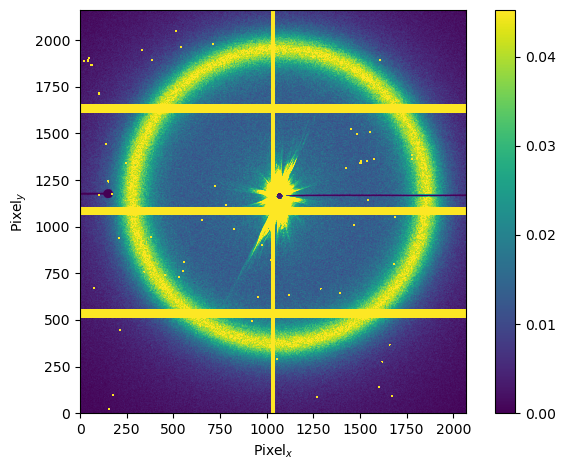

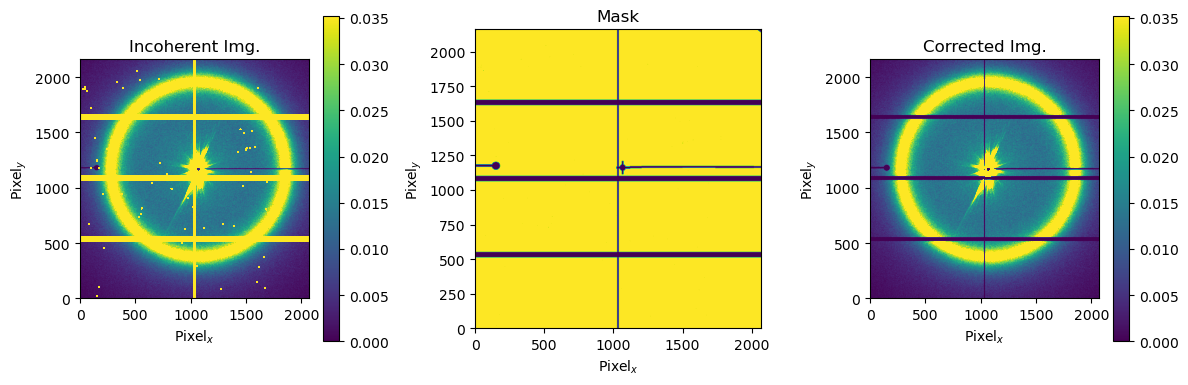

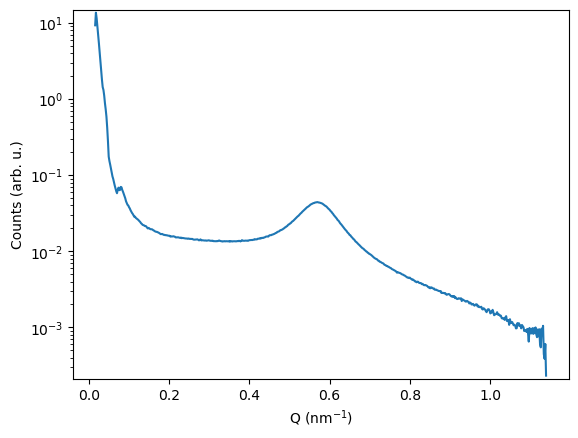

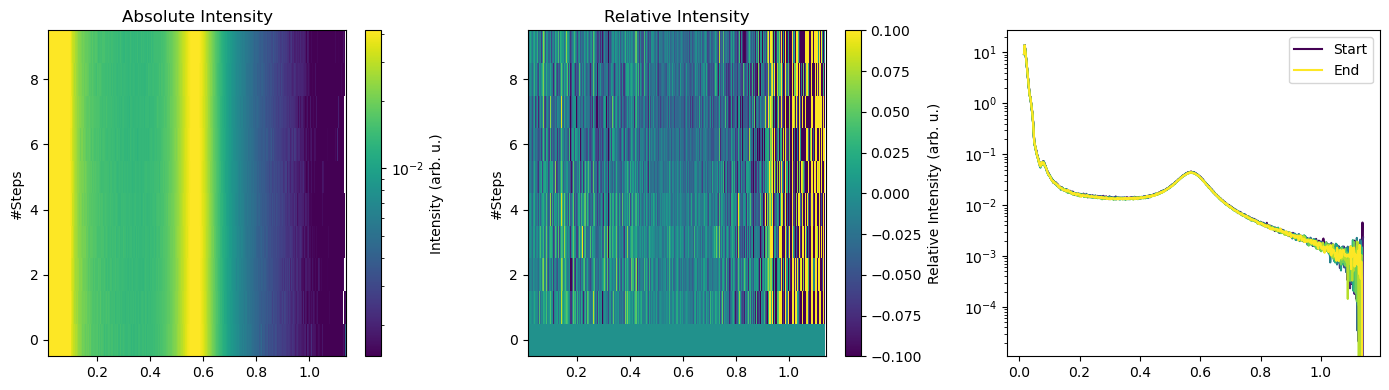

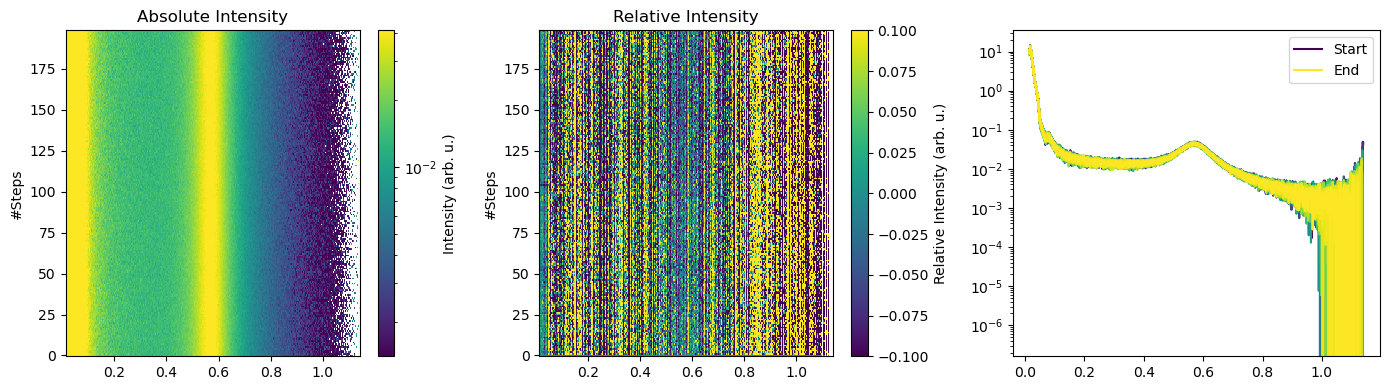

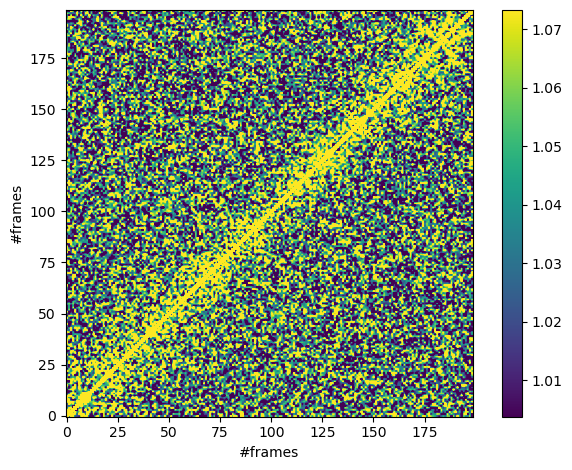

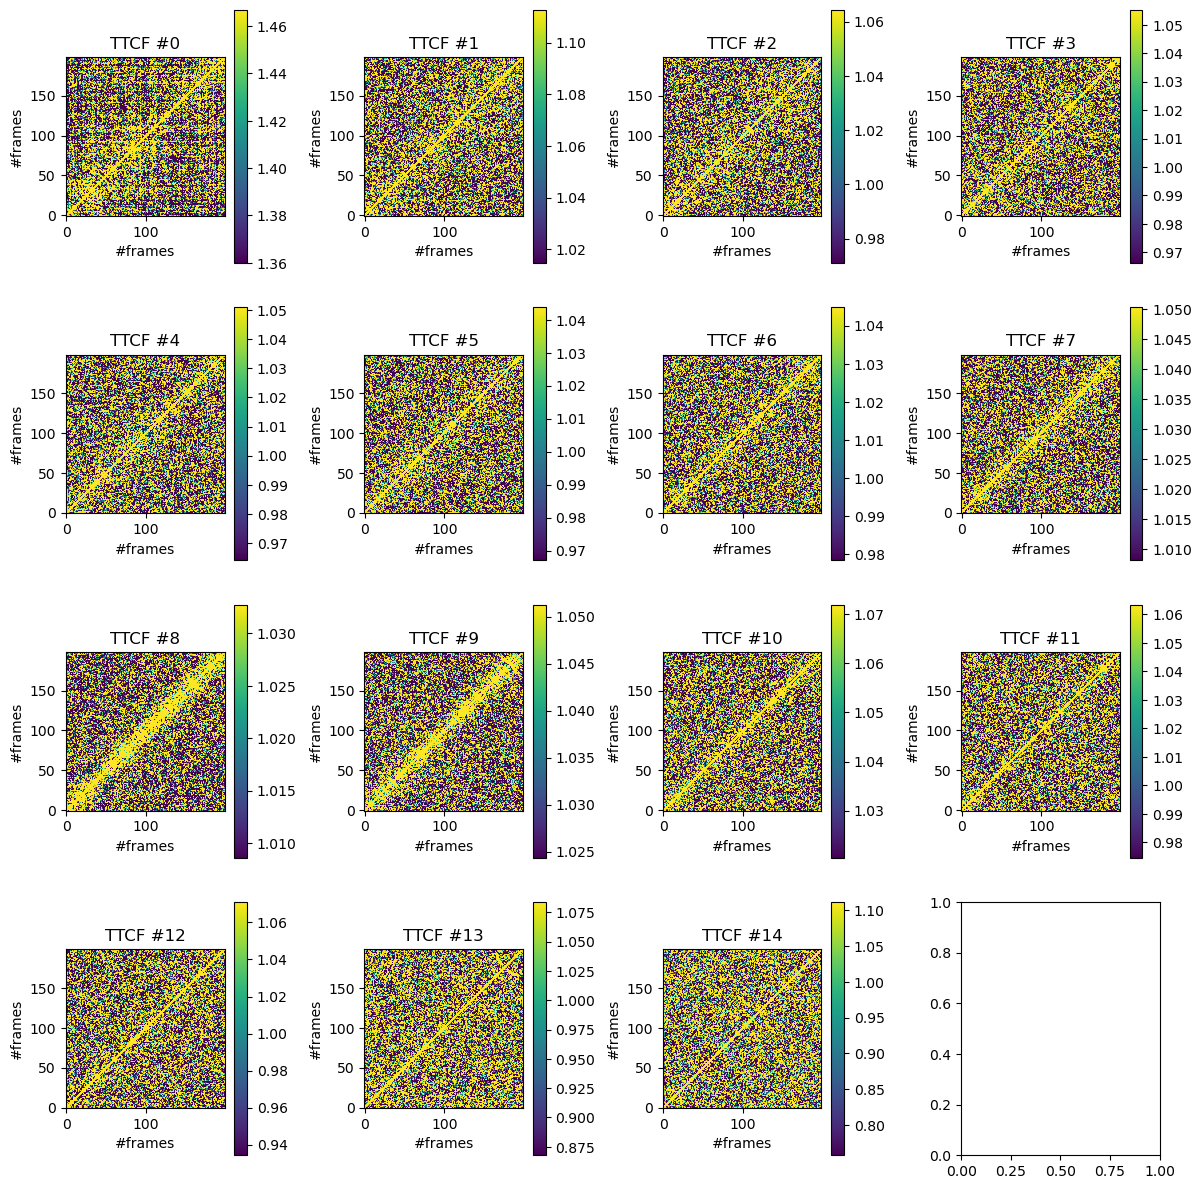

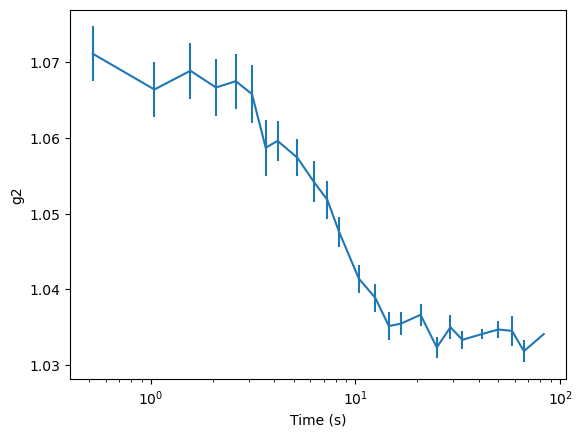

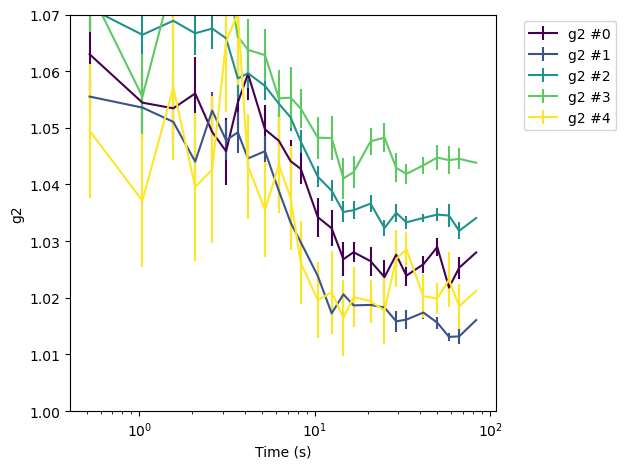

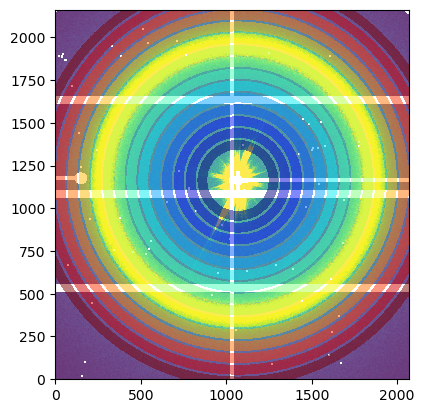

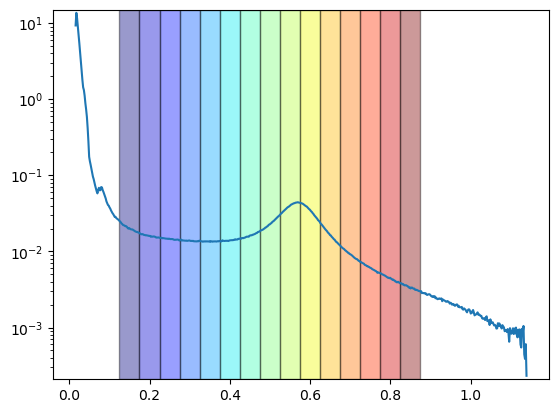

In [21]:
# incoherent images (2 options)
show_incoherent_img(incoherent_img)
show_incoherent_img(incoherent_img, mask=mask, v_limits='auto')
# SAXS curves 
show_SAXS_curve(SAXS_Q, SAXS_IofQ) # converts automatically to nm-1
# evolution/degradation
show_evolution_plots(evo_SAXS_Q*1e-9, evo_SAXS_IofQ)
show_evolution_plots(frame_resolved_SAXS_Q*1e-9, frame_resolved_SAXS_IofQ, norm_reference_idx=0)
# ttcf
show_single_ttcf(ttc_per_q_partition[9,:,:], v_limits='auto')
show_all_ttcf(ttc_per_q_partition, v_limits='auto')
# g2
show_single_g2(times_multitau, g2multitau_per_q_partition[9,:],g2error=g2errormultitau_per_q_partition[9,:] ,y_limits='auto')
show_all_g2s(times_multitau, g2multitau_per_q_partition[7:12,:],g2errors=g2errormultitau_per_q_partition[7:12,:] ,y_limits=[1,1.07])
# q_partitions
q_partitions.show_partitions2D(incoherent_img=incoherent_img_cor)
q_rings.show_q_rings(SAXS_Q, SAXS_IofQ)